<a href="https://colab.research.google.com/github/njwbilll/Tugas-4_Practical-Statistics-for-Data-Scientists-O-Reilly_Najwa-Bilqis-Al-Khalidah/blob/main/04_Regression_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4: Regression and Prediction

**Referensi:** Practical Statistics for Data Scientists (Peter Bruce, Andrew Bruce, Peter Gedeck)

***

## Ringkasan Chapter

Regresi adalah metode statistik klasik yang telah diadaptasi menjadi salah satu pondasi utama dalam machine learning untuk tugas prediksi. Tujuan utamanya adalah mengeksplorasi hubungan antara variabel prediktor (independen) dengan variabel target numerik (dependen), serta menggunakan hubungan matematis tersebut untuk memprediksi nilai target pada data baru.

Bab ini tidak hanya membahas regresi linear sederhana, tetapi juga memperluas konsep ke regresi linear berganda, penanganan variabel kategorikal, evaluasi diagnosis model, hingga pemodelan regresi non-linear menggunakan regresi polinomial.

### Topik yang Dibahas:
1. Regresi Linear Sederhana (Simple Linear Regression)
2. Regresi Linear Berganda (Multiple Linear Regression)
3. Variabel Faktor (Dummy Variables)
4. Interpretasi Persamaan Regresi dan Multikolinearitas
5. Diagnostik Regresi (Analisis Residual)
6. Regresi Polinomial dan Hubungan Non-Linear


***
## Setup: Import Library

Kita menginisialisasi environment dengan mengimpor modul standar untuk analisis data dan modul regresi dari scikit-learn serta statsmodels. Statsmodels sangat berguna untuk mendapatkan ringkasan statistik inferensial yang mendalam.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

print("Modul regresi dan analisis data berhasil dimuat.")


Modul regresi dan analisis data berhasil dimuat.


***
## 1. Regresi Linear Sederhana (Simple Linear Regression)

### Penjelasan Teori

Regresi linear sederhana memodelkan hubungan antara satu variabel prediktor (X) dan satu variabel target (Y). Model ini mengasumsikan bahwa hubungan tersebut dapat direpresentasikan oleh sebuah garis lurus.

Persamaan dasarnya adalah:
Y = b0 + b1 * X

* **Y:** Variabel target (respons).
* **X:** Variabel prediktor (fitur).
* **b0 (Intercept):** Titik potong pada sumbu Y ketika nilai X adalah nol.
* **b1 (Slope/Koefisien):** Kemiringan garis, yang menunjukkan seberapa besar perubahan pada Y untuk setiap penambahan satu unit pada X.

Algoritma regresi bekerja dengan metode Ordinary Least Squares (OLS), yaitu meminimalkan jumlah kuadrat dari residual (selisih antara nilai prediksi garis regresi dan nilai data aktual).

Persamaan Regresi Sederhana: Gaji = 42.48 + 4.67 * Pengalaman


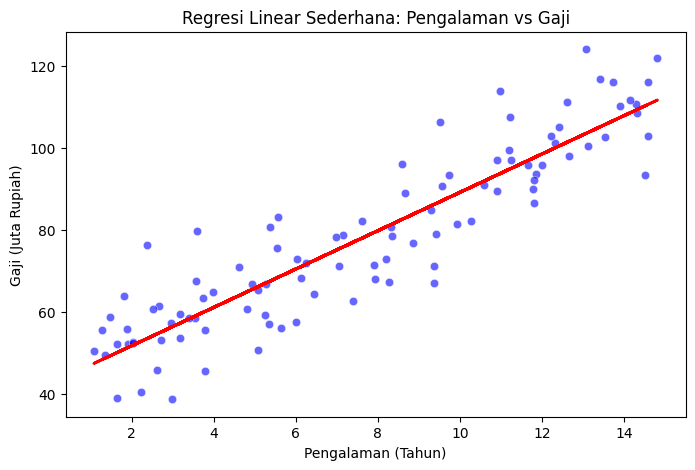

In [2]:
# Simulasi Data: Hubungan antara Pengalaman Kerja (Tahun) dan Gaji (Juta Rupiah)
np.random.seed(42)
pengalaman = np.random.uniform(1, 15, 100)
# Gaji dasar 40 juta, bertambah 5 juta per tahun, ditambah noise acak
gaji = 40 + 5 * pengalaman + np.random.normal(0, 10, 100)

df_gaji = pd.DataFrame({'Pengalaman': pengalaman, 'Gaji': gaji})

# Menginisialisasi dan melatih model Linear Regression menggunakan scikit-learn
model_slr = LinearRegression()
X_simple = df_gaji[['Pengalaman']]
y_simple = df_gaji['Gaji']
model_slr.fit(X_simple, y_simple)

intercept = model_slr.intercept_
slope = model_slr.coef_[0]

print(f"Persamaan Regresi Sederhana: Gaji = {intercept:.2f} + {slope:.2f} * Pengalaman")

# Visualisasi
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Pengalaman', y='Gaji', data=df_gaji, color='blue', alpha=0.6)
plt.plot(df_gaji['Pengalaman'], model_slr.predict(X_simple), color='red', linewidth=2)
plt.title('Regresi Linear Sederhana: Pengalaman vs Gaji')
plt.xlabel('Pengalaman (Tahun)')
plt.ylabel('Gaji (Juta Rupiah)')
plt.show()


***
## 2. Regresi Linear Berganda (Multiple Linear Regression)

### Penjelasan Teori

Di dunia nyata, fenomena kompleks jarang sekali dipengaruhi oleh satu faktor saja. Regresi linear berganda memperluas persamaan garis sederhana menjadi ruang multidimensi (hyperplane) dengan mengikutsertakan banyak variabel prediktor.

Persamaan regresi berganda:
Y = b0 + b1 * X1 + b2 * X2 + ... + bn * Xn

Dalam bagian ini, kita akan menggunakan pustaka Statsmodels karena pustaka ini menyediakan metode '.summary()' yang sangat kaya akan metrik evaluasi seperti R-squared (R kuadrat), Adjusted R-squared, P-Value, dan rentang interval kepercayaan untuk setiap koefisien.

In [3]:
# Simulasi Data Properti: Harga Rumah (Ribuan USD) berdasarkan Luas Tanah, Jumlah Kamar, dan Umur Bangunan
np.random.seed(10)
luas_tanah = np.random.normal(1500, 400, 200)
kamar = np.random.randint(2, 6, 200)
umur = np.random.uniform(1, 50, 200)

# Formulasi Harga: Harga dasar 50, tiap sqft nambah 0.1, tiap kamar nambah 15, umur ngurangin 2 per tahun
harga = 50 + (0.1 * luas_tanah) + (15 * kamar) - (2 * umur) + np.random.normal(0, 30, 200)

df_rumah = pd.DataFrame({
    'Luas': luas_tanah,
    'Kamar': kamar,
    'Umur': umur,
    'Harga': harga
})

# Mendefinisikan fitur dan target
X_multi = df_rumah[['Luas', 'Kamar', 'Umur']]
y_multi = df_rumah['Harga']

# Statsmodels mewajibkan kita menambahkan konstanta (b0) secara manual
X_multi_const = sm.add_constant(X_multi)

# Membangun model OLS (Ordinary Least Squares)
model_ols = sm.OLS(y_multi, X_multi_const).fit()

print(model_ols.summary())


                            OLS Regression Results                            
Dep. Variable:                  Harga   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     209.7
Date:                Wed, 24 Jun 2026   Prob (F-statistic):           6.47e-61
Time:                        11:22:36   Log-Likelihood:                -946.97
No. Observations:                 200   AIC:                             1902.
Df Residuals:                     196   BIC:                             1915.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         69.9181      9.934      7.038      0.0

***
## 3. Variabel Faktor (Dummy Variables)

### Penjelasan Teori

Persamaan matematis regresi hanya dapat memproses angka numerik. Namun, data operasional sangat sering memuat variabel faktor atau kategorikal (seperti lokasi geografis, jenis tipe mesin, kategori hari). Kita tidak bisa memasukkan variabel teks secara langsung.

Pendekatan standar adalah membuat variabel *Dummy* (juga dikenal sebagai *One-Hot Encoding*). Setiap kategori unik diubah menjadi kolom baru bernilai 0 atau 1.

Sangat krusial untuk menggunakan parameter 'drop_first' agar kita membuang satu level dari kategori tersebut sebagai variabel dasar (reference/baseline) untuk menghindari *Dummy Variable Trap* (situasi di mana kolom saling berkorelasi sempurna yang merusak matriks invers dalam perhitungan regresi).

In [5]:
# Menambahkan variabel kategorikal 'Lokasi' ke dalam dataset rumah
lokasi = np.random.choice(['Pusat Kota', 'Pinggiran', 'Pedesaan'], size=200)
df_rumah['Lokasi'] = lokasi

# Modifikasi harga berdasarkan lokasi
penyesuaian_lokasi = {'Pusat Kota': 80, 'Pinggiran': 20, 'Pedesaan': -30}
df_rumah['Harga'] = df_rumah['Harga'] + df_rumah['Lokasi'].map(penyesuaian_lokasi)

# Membuat variabel Dummy, menjatuhkan kategori pertama sebagai reference baseline
df_rumah_encoded = pd.get_dummies(df_rumah, columns=['Lokasi'], drop_first=True, dtype=int)  # ✅ tambahkan dtype=int

print("Beberapa baris dataset setelah Dummy Encoding:")
display(df_rumah_encoded.head())

# Melatih model regresi berganda dengan variabel faktor yang baru
X_dummy = sm.add_constant(df_rumah_encoded.drop('Harga', axis=1))
y_dummy = df_rumah_encoded['Harga']
model_dummy = sm.OLS(y_dummy, X_dummy).fit()

print("\nKoefisien yang dihasilkan dari regresi dengan variabel dummy:")
print(model_dummy.params)


Beberapa baris dataset setelah Dummy Encoding:


,Luas,Kamar,Umur,Harga,Lokasi_Pinggiran,Lokasi_Pusat Kota
0,2032.634602,3,15.148009,333.843150,0,0
1,1786.111590,5,36.319195,194.088453,1,0
2,881.839883,2,27.989497,156.270691,0,1
3,1496.646460,4,42.090274,272.619824,0,1
4,1748.534390,3,29.436236,260.567589,0,1



Koefisien yang dihasilkan dari regresi dengan variabel dummy:
const                 75.564172
Luas                   0.093952
Kamar                  9.577155
Umur                  -2.200508
Lokasi_Pinggiran      49.811783
Lokasi_Pusat Kota    115.857876
dtype: float64


***
## 4. Multikolinearitas dan Interpretabilitas

### Penjelasan Teori

Ketika dua atau lebih variabel prediktor saling berkorelasi erat (misalnya variabel Luas Bangunan dan Jumlah Kamar), hal ini menciptakan kondisi Multikolinearitas. Model tidak lagi mampu membedakan dengan jelas efek individual dari masing-masing variabel terhadap target. Hal ini menyebabkan fluktuasi liar pada nilai koefisien dan memperlebar standard error.

Kita mengukur multikolinearitas dengan VIF (Variance Inflation Factor). Sebagai pedoman praktis:
* VIF sama dengan 1: Tidak ada korelasi antar prediktor.
* VIF antara 1 hingga 5: Korelasi moderat (masih bisa ditoleransi).
* VIF lebih besar dari 5 atau 10: Multikolinearitas tinggi, fitur harus dianalisis untuk dibuang atau digabungkan.

In [6]:
def calculate_vif(X_df):
    vif_data = pd.DataFrame()
    vif_data["Fitur"] = X_df.columns
    # Menghitung VIF untuk setiap variabel fitur
    vif_data["VIF"] = [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
    return vif_data

# Kita akan menyertakan data untuk cek VIF
# Karena statsmodels memerlukan numerik, kita gunakan X_dummy tapi buang nilai konstan untuk perhitungan VIF
X_for_vif = df_rumah_encoded.drop('Harga', axis=1).astype(float)

vif_results = calculate_vif(X_for_vif)
print("Variance Inflation Factor (VIF) untuk setiap fitur:")
display(vif_results)

print("\nCatatan: Jika VIF bernilai kecil, interpretasi koefisien kita sangat valid dan saling independen.")


Variance Inflation Factor (VIF) untuk setiap fitur:


,Fitur,VIF
0,Luas,9.429753
1,Kamar,10.024572
2,Umur,3.811474
3,Lokasi_Pinggiran,1.863186
4,Lokasi_Pusat Kota,1.742164



Catatan: Jika VIF bernilai kecil, interpretasi koefisien kita sangat valid dan saling independen.


***
## 5. Diagnostik Regresi (Analisis Residual)

### Penjelasan Teori

Regresi linear memiliki beberapa asumsi statistik ketat yang harus dipenuhi agar model bisa dipercaya. Kita memvalidasi asumsi ini dengan memeriksa residual (sisa galat antara nilai aktual dengan prediksi model).

1. **Asumsi Normalitas Galat:** Residual idealnya berdistribusi normal di sekitar angka nol. Kita bisa mengeceknya dengan Histogram dan QQ-Plot.
2. **Asumsi Homoskedastisitas:** Varians dari galat seharusnya konstan di seluruh rentang nilai prediksi. Jika plot residual membentuk pola corong (melebar di akhir), itu menandakan heteroskedastisitas.
3. **Pengaruh Outlier:** Analisis nilai jarak (Leverage) dapat mengetahui apakah ada nilai ekstrim tunggal yang menarik kemiringan garis secara paksa.

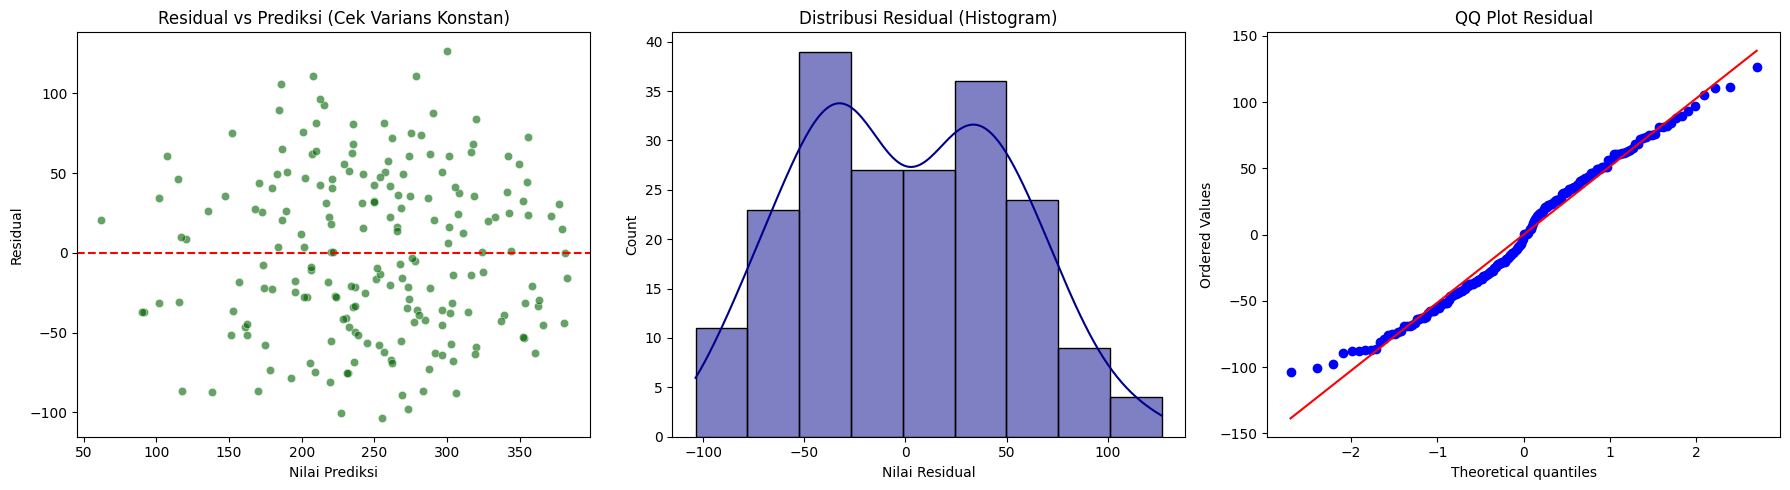

In [7]:
# Ekstraksi prediksi dan residual dari model
prediksi = model_dummy.fittedvalues
residual = model_dummy.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Residual vs Fitted (Cek Homoskedastisitas)
sns.scatterplot(x=prediksi, y=residual, ax=axes[0], alpha=0.6, color='darkgreen')
axes[0].axhline(0, color='red', linestyle='dashed')
axes[0].set_title('Residual vs Prediksi (Cek Varians Konstan)')
axes[0].set_xlabel('Nilai Prediksi')
axes[0].set_ylabel('Residual')

# Plot 2: Histogram Residual (Cek Normalitas)
sns.histplot(residual, kde=True, ax=axes[1], color='darkblue')
axes[1].set_title('Distribusi Residual (Histogram)')
axes[1].set_xlabel('Nilai Residual')

# Plot 3: QQ Plot (Cek Detail Normalitas)
stats.probplot(residual, dist="norm", plot=axes[2])
axes[2].set_title('QQ Plot Residual')

plt.tight_layout()
plt.show()


***
## 6. Regresi Polinomial dan Hubungan Non-Linear

### Penjelasan Teori

Regresi linear sangat payah saat harus menangani pola data melengkung (non-linear). Untuk mengatasi hal tersebut tanpa harus pindah ke algoritma neural network atau pohon keputusan, kita dapat menerapkan perluasan regresi polinomial.

Regresi polinomial mengubah fitur X asli menjadi berbagai derajat pangkat. Misalnya, derajat dua akan menghasilkan fitur X pangkat dua. Secara teknis, model regresi masih bekerja secara "linear" terhadap variabel fitur baru tersebut, namun grafiknya di dunia nyata akan berbentuk lengkungan kurva kuadratik, kubik, dan seterusnya.

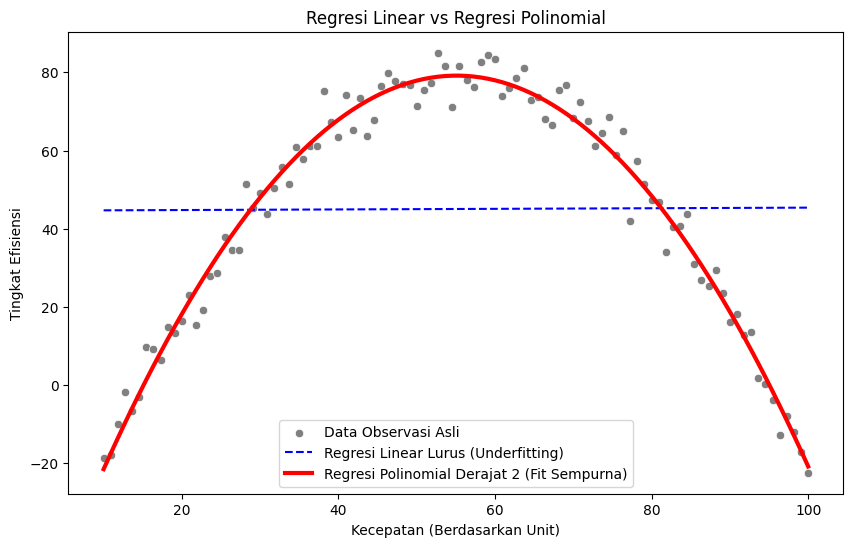

In [8]:
# Simulasi data non-linear: Efisiensi bahan bakar terhadap Kecepatan Mesin (RPM)
np.random.seed(42)
kecepatan = np.linspace(10, 100, 100)
# Hubungan berbentuk kurva U terbalik (efisiensi puncaknya di kecepatan menengah)
efisiensi = -0.05 * (kecepatan - 55)**2 + 80 + np.random.normal(0, 5, 100)

df_nonlinear = pd.DataFrame({'Kecepatan': kecepatan, 'Efisiensi': efisiensi})
X_nl = df_nonlinear[['Kecepatan']]
y_nl = df_nonlinear['Efisiensi']

# 1. Melatih Model Linear biasa (akan gagal menangkap pola)
model_lin = LinearRegression().fit(X_nl, y_nl)
pred_lin = model_lin.predict(X_nl)

# 2. Transformasi ke Polinomial Derajat 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_nl)

# 3. Melatih Model dengan fitur polinomial
model_poly = LinearRegression().fit(X_poly, y_nl)
pred_poly = model_poly.predict(X_poly)

# Visualisasi Perbandingan
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Kecepatan', y='Efisiensi', data=df_nonlinear, color='gray', label='Data Observasi Asli')
plt.plot(kecepatan, pred_lin, color='blue', label='Regresi Linear Lurus (Underfitting)', linestyle='dashed')
plt.plot(kecepatan, pred_poly, color='red', label='Regresi Polinomial Derajat 2 (Fit Sempurna)', linewidth=3)
plt.title('Regresi Linear vs Regresi Polinomial')
plt.xlabel('Kecepatan (Berdasarkan Unit)')
plt.ylabel('Tingkat Efisiensi')
plt.legend()
plt.show()
